# Finetuning Evaluation vs. RAG solutions

This notebook compares the evaluation results from the IT Support RAG with the Finetuning alternative using the model Qwen2.5-instruct on the same tickets base by using as evaluator an LLM-as-a-judge approach with the [DeepEval](https://deepeval.com/) library in local to produce different relevants metrics for the FT scenario. 

The chosen LLM that acts as judge was `llama-4-scout-17b-16e-instruct` developed by Meta.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 120)

## 1. Load and normalize evaluation outputs

Evaluation results extracted from API admin portal presented in CSV format are loaded into dataframes.

In [2]:
RESULT_SOURCES = {
    'FT-Expert': '../raw_results/ft_expert_results_050426.csv',
    'RAG_VectorOnly-Expert': '../raw_results/vector_only_expert_results_050426.csv',
    'RAG_Hybrid-Expert': '../raw_results/hybrid_expert_results_050426.csv',
    'RAG_HybridHyDE-Expert': '../raw_results/hybrid_hyde_expert_results_050426.csv',
    'FT-Operational': '../raw_results/ft_operational_results_050426.csv',
    'RAG_VectorOnly-Operational': '../raw_results/vector_only_operational_results_050426.csv',
    'RAG_Hybrid-Operational': '../raw_results/hybrid_operational_results_050426.csv',
    'RAG_HybridHyDE-Operational': '../raw_results/hybrid_hyde_operational_results_050426.csv',
}

GOLDEN_SOURCES = {
    'Expert': '../goldens/expert.json',
    'Operational': '../goldens/operational.json',
}

def load_table(path):
    path = Path(path)
    if not path.exists():
        return pd.DataFrame()
    if path.suffix.lower() == '.csv':
        return pd.read_csv(path)
    if path.suffix.lower() == '.json':
        with path.open('r', encoding='utf-8') as handle:
            data = json.load(handle)
        if isinstance(data, list):
            return pd.DataFrame(data)
        return pd.DataFrame([data])
    raise ValueError(f'Unsupported file type: {path.suffix}')

def normalize_endpoint_export(df):
    if df.empty:
        return df
    rename_map = {
        'question': 'Question',
        'query': 'Question',
        'actual_answer': 'Actual Answer',
        'answer': 'Actual Answer',
        'result': 'Actual Answer',
        'expected_output': 'Expected Output',
        'reference': 'Expected Output',
        'latency': 'latency_s',
    }
    return df.rename(columns={source: target for source, target in rename_map.items() if source in df.columns})

def load_evaluation_runs(source_map):
    frames = []
    for run_name, file_path in source_map.items():
        frame = load_table(file_path)
        if frame.empty:
            print(f'Skipping missing or empty file for {run_name}: {file_path}')
            continue
        frame = normalize_endpoint_export(frame.copy())
        if 'kb' not in frame:
            frame = frame[[
                "Question", 
                "Actual Answer", 
                "Expected Output", 
                "Correctness Score", 
                "Correctness Reason", 
                "AnswerRelevancy Score", 
                "AnswerRelevancy Reason"
                ]]
        
        frame['run_name'] = run_name
        if '-' in run_name:
            system_type, scenario = run_name.split('-', 1)
        else:
            system_type, scenario = run_name, 'Unknown'
        frame['system_type'] = system_type
        frame['scenario'] = scenario
        frames.append(frame)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

all_results_df = load_evaluation_runs(RESULT_SOURCES)

print(f"Loaded rows: {len(all_results_df)}")
display(all_results_df.head())

Loaded rows: 240


,Question,Actual Answer,Expected Output,Correctness Score,Correctness Reason,AnswerRelevancy Score,AnswerRelevancy Reason,run_name,system_type,scenario
0,¿Cuál es el procedimiento técnico para identificar la jerarquía de una cadena de bloqueo en SQL Server sin usar sp_w...,"El comando más adecuado para identificar el bloqueo principal es: SELECT request_session_id, blocked_session_id FROM...",Se debe ejecutar un script que consulte la vista sys.dm_exec_requests realizando un CROSS APPLY con sys.dm_exec_sql_...,0.2,The Actual Output provides some information about identifying locks in SQL Server but does not accurately reflect th...,0.666667,The score is 0.67 because while the response attempts to address the question about identifying the hierarchy of a b...,FT-Expert,FT,Expert
1,¿Qué validación es obligatoria realizar antes de ejecutar un comando KILL en una transacción de base de datos muy an...,La validación de consistencia de la transacción (Durability check) antes de autorizar el cierre forzado.,Es imperativo verificar el estado de la transacción en sys.dm_tran_active_transactions. Si la columna transaction_be...,0.0,The Actual Output does not match the Expected Output in terms of content and format. The Expected Output emphasizes ...,0.800000,The score is 0.80 because while the output addresses the general requirement for transactions before executing a KIL...,FT-Expert,FT,Expert
2,"Si una réplica secundaria de SQL Server está en estado SUSPENDED por corrupción lógica, ¿cómo se reinicializa correc...","Para reinicializar una réplica secundaria de SQL Server de forma correcta, siga estos pasos: Eliminación del archivo...","Se debe eliminar la base de datos de la réplica secundaria, realizar un Backup de Log en la primaria, restaurar la b...",0.2,"The Actual Output provides some steps for reinitializing a SQL Server secondary replica, but they are incomplete and...",1.000000,"The score is 1.00 because the actual output perfectly addresses the input question with no irrelevant statements, pr...",FT-Expert,FT,Expert
3,¿Cómo se puede diferenciar un punto de acceso Wi-Fi vecino de una amenaza tipo Rogue AP en entornos Windows?,"Para identificar amenazas de tipo Rogue AP, es necesario verificar la autorización del dispositivo con el servidor d...",Utilizando el comando de PowerShell 'netsh wlan show networks mode=bssid' para identificar el BSSID sospechoso. Se c...,0.2,The Actual Output attempts to address the Input question but lacks specificity and does not align with the Expected ...,1.000000,"The score is 1.00 because the actual output is perfectly relevant to the input, with no irrelevant statements detect...",FT-Expert,FT,Expert
4,¿Qué medida de contención inmediata debe aplicarse en la controladora Wi-Fi ante la detección de un Evil Twin?,La medida de contención inmediata recomendada es la emisión de un anuncio de caída de red y notificación al usuario..,"Se debe activar la función 'Rogue AP Containment', la cual inunda el canal con paquetes de de-autenticación para for...",0.0,The Actual Output does not match the Expected Output in terms of content. The Actual Output suggests a notification ...,1.000000,"The score is 1.00 because the response is perfectly relevant to the input question, with no irrelevant statements de...",FT-Expert,FT,Expert


## 2. Validate schema and metric coverage

Reports if the schema on every file is correct and standardizes the output so every run can be compared under the same reporting rules.


In [3]:
def validate_results_schema(df):
    if df.empty:
        return {"status": "empty", "missing": []}
    required = ["Question", "Actual Answer", "Expected Output", "system_type", "scenario"]
    missing = [column for column in required if column not in df.columns]
    return {"status": "ok" if not missing else "missing", "missing": missing}

def build_summary_table(df, metric_columns):
    if df.empty or not metric_columns:
        return pd.DataFrame()
    group_columns = ['system_type', 'scenario']
    numeric_columns = metric_columns + (['latency_s'] if 'latency_s' in df.columns else [])
    return df.groupby(group_columns, as_index=False)[numeric_columns].mean()

def detect_metric_columns(df):
    return [column for column in df.columns if column.endswith(' Score')] if not df.empty else []

schema_status = validate_results_schema(all_results_df)
print(schema_status)

metric_columns = detect_metric_columns(all_results_df)
summary_df = build_summary_table(all_results_df, metric_columns)

if not summary_df.empty:
    display(summary_df.round(4))
else:
    print("Warning: summary_df is empty. Please check the data loading step.")

{'status': 'ok', 'missing': []}


,system_type,scenario,Correctness Score,AnswerRelevancy Score
0,FT,Expert,0.1733,0.5211
1,FT,Operational,0.2133,0.5278
2,RAG_Hybrid,Expert,0.1533,0.5945
3,RAG_Hybrid,Operational,0.1933,0.5631
4,RAG_HybridHyDE,Expert,0.1667,0.5585
5,RAG_HybridHyDE,Operational,0.1667,0.5545
6,RAG_VectorOnly,Expert,0.1600,0.5661
7,RAG_VectorOnly,Operational,0.2200,0.5201


## 3. Metric reason review

A table that shows the judge reason is constructed for a better visualization of the conclusions for every question made to the Fine-tuning.

In [4]:
def build_reason_table(df, max_rows=8):
    reason_columns = [column for column in df.columns if column.endswith(' Reason')]
    if df.empty or not reason_columns:
        return pd.DataFrame()
    preview_columns = ['system_type', 'scenario', 'Question'] + reason_columns
    return df[preview_columns].head(max_rows)

reason_snapshot_df = build_reason_table(all_results_df)

if reason_snapshot_df.empty:
    print('No metric reasons are available in the current dataset.')
else:
    display(reason_snapshot_df)

    scenario_reason_summary = (
        reason_snapshot_df.groupby(['system_type', 'scenario'], as_index=False)
        .first()
    )
    display(scenario_reason_summary)

,system_type,scenario,Question,Correctness Reason,AnswerRelevancy Reason
0,FT,Expert,¿Cuál es el procedimiento técnico para identificar la jerarquía de una cadena de bloqueo en SQL Server sin usar sp_w...,The Actual Output provides some information about identifying locks in SQL Server but does not accurately reflect th...,The score is 0.67 because while the response attempts to address the question about identifying the hierarchy of a b...
1,FT,Expert,¿Qué validación es obligatoria realizar antes de ejecutar un comando KILL en una transacción de base de datos muy an...,The Actual Output does not match the Expected Output in terms of content and format. The Expected Output emphasizes ...,The score is 0.80 because while the output addresses the general requirement for transactions before executing a KIL...
2,FT,Expert,"Si una réplica secundaria de SQL Server está en estado SUSPENDED por corrupción lógica, ¿cómo se reinicializa correc...","The Actual Output provides some steps for reinitializing a SQL Server secondary replica, but they are incomplete and...","The score is 1.00 because the actual output perfectly addresses the input question with no irrelevant statements, pr..."
3,FT,Expert,¿Cómo se puede diferenciar un punto de acceso Wi-Fi vecino de una amenaza tipo Rogue AP en entornos Windows?,The Actual Output attempts to address the Input question but lacks specificity and does not align with the Expected ...,"The score is 1.00 because the actual output is perfectly relevant to the input, with no irrelevant statements detect..."
4,FT,Expert,¿Qué medida de contención inmediata debe aplicarse en la controladora Wi-Fi ante la detección de un Evil Twin?,The Actual Output does not match the Expected Output in terms of content. The Actual Output suggests a notification ...,"The score is 1.00 because the response is perfectly relevant to the input question, with no irrelevant statements de..."
5,FT,Expert,"Si se identifica un Rogue AP conectado físicamente a la red cableada, ¿qué acción debe realizar el administrador de ...","The Actual Output partially addresses the issue by mentioning identification and action on the port, but it does not...",The score is 0.67 because although the response attempts to address the issue of a Rogue AP connected to the network...
6,FT,Expert,¿Cuál es el comando de PowerShell para bloquear el acceso de un usuario a Microsoft 365 de forma inmediata por una a...,The Actual Output does not match the Expected Output in terms of content and format. The command provided in the Act...,"The score is 1.00 because the actual output is perfectly relevant to the input, with no irrelevant statements detect..."
7,FT,Expert,¿Cómo se puede mitigar una saturación de la red troncal causada por bucles de sincronización de OneDrive mediante GPOs?,The Actual Output does not match the Expected Output in terms of content and format. The Expected Output suggests co...,"The score is 0.00 because the actual output contains completely irrelevant information, specifically mentioning modi..."


,system_type,scenario,Question,Correctness Reason,AnswerRelevancy Reason
0,FT,Expert,¿Cuál es el procedimiento técnico para identificar la jerarquía de una cadena de bloqueo en SQL Server sin usar sp_w...,The Actual Output provides some information about identifying locks in SQL Server but does not accurately reflect th...,The score is 0.67 because while the response attempts to address the question about identifying the hierarchy of a b...


## 4. KPI tables

Comparing systems and scenarios side by side by presenting the mean of every different approach and metrics evaluated.

In [5]:
def build_wins_table(summary_df, metric_columns):
    if summary_df.empty or not metric_columns:
        return pd.DataFrame()
    rows = []
    for scenario_name in summary_df['scenario'].dropna().unique():
        subset = summary_df[summary_df['scenario'] == scenario_name]
        for metric in metric_columns:
            best_row = subset.loc[subset[metric].idxmax()]
            rows.append({
                'scenario': scenario_name,
                'metric': metric,
                'winner': best_row['system_type'],
                'score': best_row[metric],
            })
    return pd.DataFrame(rows)

wins_df = build_wins_table(summary_df, metric_columns)
display(wins_df)

if "latency_s" in summary_df.columns:
    display(summary_df[["system_type", "scenario", "latency_s"]])

,scenario,metric,winner,score
0,Expert,Correctness Score,FT,0.173333
1,Expert,AnswerRelevancy Score,RAG_Hybrid,0.594476
2,Operational,Correctness Score,RAG_VectorOnly,0.220000
3,Operational,AnswerRelevancy Score,RAG_Hybrid,0.563094


## 5. Visual analytics

Rendering Metric Bars...


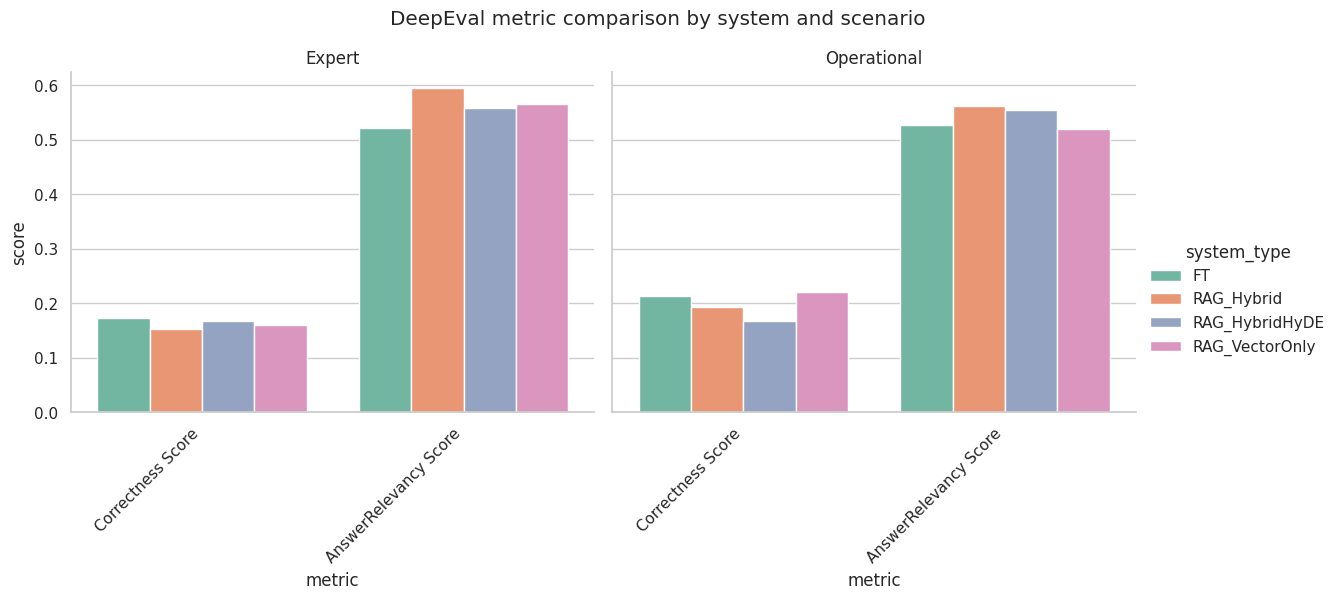

Rendering Metric Distributions...


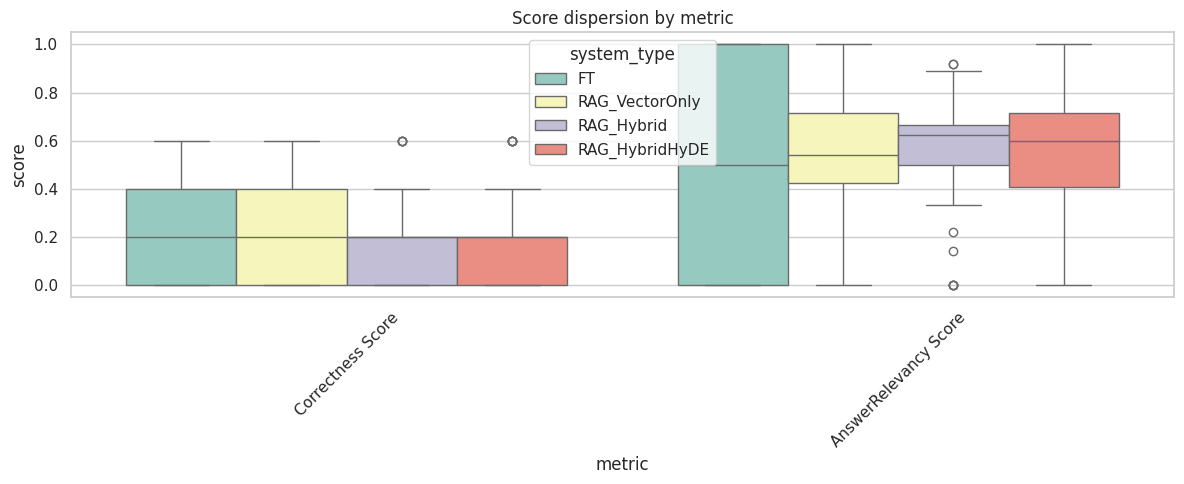

Rendering Latency Scatter Plot...
Latency is not available in the current dataset.


In [6]:
def plot_metric_bars(summary_df, metric_columns):
    if summary_df.empty or not metric_columns:
        print("No data available for metric bars yet.")
        return
    melted = summary_df.melt(id_vars=["system_type", "scenario"], value_vars=metric_columns, var_name="metric", value_name="score")
    g = sns.catplot(
        data=melted,
        kind="bar",
        x="metric",
        y="score",
        hue="system_type",
        col="scenario",
        palette="Set2",
        height=4.5,
        aspect=1.3,
        sharey=True,
    )
    g.set_xticklabels(rotation=45, ha="right")
    g.set_titles("{col_name}")
    g.figure.suptitle("DeepEval metric comparison by system and scenario", y=1.05)
    plt.show()

def plot_metric_distributions(df, metric_columns):
    if df.empty or not metric_columns:
        print("No data available for distribution plots yet.")
        return
    melted = df.melt(id_vars=["system_type", "scenario"], value_vars=metric_columns, var_name="metric", value_name="score")
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.boxplot(data=melted, x="metric", y="score", hue="system_type", ax=ax, palette="Set3")
    ax.set_title("Score dispersion by metric")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

def plot_latency_scatter(df):
    if df.empty or "latency_s" not in df.columns:
        print("Latency is not available in the current dataset.")
        return
    quality_columns = [column for column in detect_metric_columns(df) if column != "latency_s"]
    df_plot = df.copy()
    df_plot["quality_mean"] = df_plot[quality_columns].mean(axis=1)
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.scatterplot(data=df_plot, x="latency_s", y="quality_mean", hue="system_type", style="scenario", s=90, ax=ax)
    ax.set_title("Latency vs average quality")
    ax.set_xlabel("Latency (s)")
    ax.set_ylabel("Average quality score")
    plt.tight_layout()
    plt.show()

# Execute plot functions
print("Rendering Metric Bars...")
plot_metric_bars(summary_df, metric_columns)

print("Rendering Metric Distributions...")
plot_metric_distributions(all_results_df, metric_columns)

print("Rendering Latency Scatter Plot...")
plot_latency_scatter(all_results_df)

### Análisis Comparativo (FT vs Variantes de RAG)

- **Correctness (Precision)**:
  - In the **expert** scenario, the Fine-Tuning system (FT) wins for a slight margin, reaching an average score of `0.1733`, closely followed by **RAG_HybridHyDE** (`0.1667`).
  - In the **operational** scenario, the results are reversed and **RAG_VectorOnly** leads with an average score of `0.2200`, leaving FT in a close second place with `0.2133`.
  - *Interpretation*: In correctness terms, all the system presents very low scores, suggesting that the golden standards are not reached by the AI solution. This is something that affects all the systems involved, not being able to mark remarkable difference accross them.

- **Answer Relevancy (Relevancia de Respuesta)**:
  - Every variant of **RAG** outperforms the **FT** approach on all the scenarios.
  - In the **Expert** golden dataset, **RAG_Hybrid** is undoubtef indisputably winner with `0.5945`, while FT is relegated to the background (`0.5211`).
  - In the **Operational** one, **RAG_Hybrid** also outperforms with `0.5631` (closely followed by HybridHyDE), while FT and VectorOnly leave very similar metrics (~0.52).
  - *Intepretation*: The Hybrid search strategy provides the best semantic and keyword context to the RAG generator, giving it structure and relevance to answer the point, even if the final data assertion is incorrect. Fine-Tuning and VectorOnly typically operate at a lower level, adapting to the tone or context of the operational query.

- **Riesgo y Dispersión de Modelos**:
  - The low Correctness scores strongly suggest that the baseline capabilities are far from production level. The vector-only RAG configuration can salvage some points in operations, but Hybrid is preferable if consistency and on-topic responsiveness are the goal.

### 7. Conclusión del Reporte

**General Summary**:
1. **Absolute Quality (Correctness)** is extremely low in both approaches and across the different strategies (around ~16%-22% at their peaks). Neither system, in any of its versions, is operating at an optimal level for high-confidence deployment.

2. **Fine-Tuning (FT) vs. RAG**: FT narrowly outperforms **Expert** over RAG_HybridHyDE, but in the **Operational** scenario, it loses first place in Correctness by 0.01 to **RAG_VectorOnly**.

3. **Retrieval-Augmented Generation (RAG) - Relevance**: RAG's Hybrid strategies (`Hybrid` and `HybridHyDE`) exhibit significantly superior performance in **Answer Relevance**. They provide a relevant and coherent structure to the response (in the 60th percentile), giving FT a significant advantage.

**Current Deficiencies**:
- The base `Correctness` metric suggests deep flaws: either the Golden Dataset is not well aligned in complexity with the provided knowledge, or RAG's retrieval strategies are completely misguided, leaving the underlying LLMs to attempt off-topic responses to the required tasks.

- Even the base Fine-Tuning is stuck at the same level where RAG can operate, finding "VectorSolo" results with the query.

**Immediate Recommendations**:
- Move to RAG **Hybrid** for the time being to get a more coherent `Answer Relevance` (0.59 vs. FT's 0.52), and work on relocating the knowledge base for RAG.

- Analyze the `Correctness Reason` column to discern whether the generated responses are being penalized by formatting, assertiveness, or a real lack of raw data on the problem.